In [1]:
import os
import yaml
import pandas as pd

In [2]:
with open ('../configs/config.yaml', 'r') as stream:
    try:
        cfg = yaml.safe_load(stream)
        print(cfg)
    except yaml.YAMLError as exc:
        print(exc) 

{'random_seed': 42, 'data': {'raw_path': 'data/raw/womens_clothing_ecommerce_reviews_balanced.csv', 'processed_dir': 'data/processed', 'text_column': 'review_body', 'sentiment_label': 'SENTIMENT', 'rating_label': 'RATING', 'recommend_label': 'RECOMMEND'}, 'preprocessing': {'lowercase': True, 'strip_punctuation': True, 'remove_numbers': False, 'handle_negations': True, 'lemmatize': True, 'stopwords': 'english'}, 'vectorization': {'type': 'tfidf', 'ngram_range': [1, 2], 'max_features': 20000, 'min_df': 2}, 'evaluation': {'cv_folds': 5}}


In [3]:
# where is the data csv file located
print(cfg['data']['raw_path'])

# where is the 

data/raw/womens_clothing_ecommerce_reviews_balanced.csv


In [4]:
df = pd.read_csv('../' + cfg['data']['raw_path'])

In [5]:
! git branch

* feat/phas1-data-audit
  main


In [6]:
df.head()

,sentiment,review_body,product_category
0,-1,This suit did nothing for me. the top has zero...,Swim
1,-1,Like other reviewers i saw this dress on the ...,Dresses
2,-1,I wish i had read the reviews before purchasin...,Knits
3,-1,I ordered these pants in my usual size (xl) an...,Legwear
4,-1,I noticed this top on one of the sales associa...,Knits


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7110 entries, 0 to 7109
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   sentiment         7110 non-null   int64 
 1   review_body       7110 non-null   object
 2   product_category  7110 non-null   object
dtypes: int64(1), object(2)
memory usage: 166.8+ KB


In [8]:
for col in df.columns:
    print("The number of missing values in ", col, "is", df[col].isna().sum())

The number of missing values in  sentiment is 0
The number of missing values in  review_body is 0
The number of missing values in  product_category is 0


In [9]:
! git branch

* feat/phas1-data-audit
  main


In [10]:
# Check for empty strings
len(df[df['review_body'].str.strip() == ""]) + len(df[df['review_body'] == " "])

0

In [11]:
df['review_body'].duplicated().sum()

np.int64(1)

In [12]:
df[df['review_body'].duplicated(keep = False) == True]

,sentiment,review_body,product_category
259,-1,I purchased this and another eva franco dress ...,Dresses
2071,-1,I purchased this and another eva franco dress ...,Dresses


The label match for the duplicated rows, so its a safe duplicate

### Class balance

In [13]:
df['sentiment'].value_counts()

sentiment
-1    2370
 0    2370
 1    2370
Name: count, dtype: int64

In [14]:
df['sentiment'].value_counts()/df['sentiment'].value_counts().sum()

sentiment
-1    0.333333
 0    0.333333
 1    0.333333
Name: count, dtype: float64

<Axes: xlabel='sentiment', ylabel='count'>

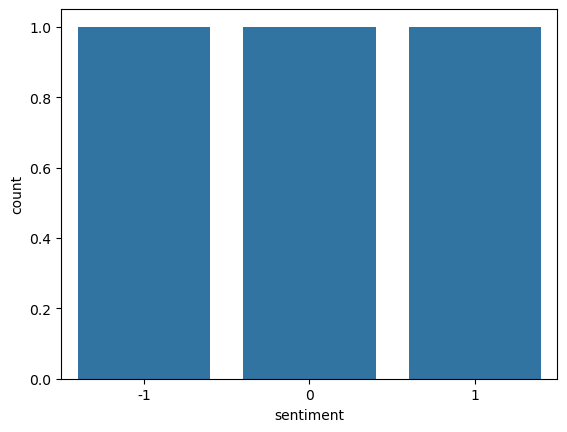

In [15]:
import seaborn as sns
sns.countplot(df['sentiment'].value_counts())

it sound balanced

In [16]:
# creating review length 
df['review_length'] = df['review_body'].apply(lambda x : len(x.split()))

In [17]:
df[df['review_length'] < 7]

,sentiment,review_body,product_category,review_length
348,-1,So much right but then....too short.,Blouses,6
1086,-1,Super itchy! had to return.,Legwear,5
2218,-1,Totally see through.,Lounge,3
2246,-1,Unforgiving to even your smallest imperfections.,Dresses,6
2430,0,Very pretty romantic,Sleep,3
2697,0,The sweater is cute but scratchy.,Sweaters,6
2971,0,Cute but too thick and rough,Sweaters,6
3794,0,Love the feel and comfort,Knits,5
4023,0,I never write reviews,Dresses,4
4720,0,Low waisted weird liner.,Pants,4


In [18]:
df['review_length'].describe()

count    7110.000000
mean       61.018847
std        27.680663
min         2.000000
25%        38.000000
50%        60.000000
75%        88.000000
max       115.000000
Name: review_length, dtype: float64

In [19]:
'So much right but then....too short.'.split()

['So', 'much', 'right', 'but', 'then....too', 'short.']

In [20]:
df[df['review_length'] < 3].sum()

sentiment                     1
review_body         Comfy cozy!
product_category          Knits
review_length                 2
dtype: object

In [21]:
pd.set_option('display.max_colwidth', None)

In [22]:
df[df['sentiment'] == 1].sample(5)

,sentiment,review_body,product_category,review_length
6093,1,I bought this dress after i had overnighted a different one and it wasn't going to be delivered on time. i'm so happy that i bought this dress. its so comfortable and easy to wear. i got lots of compliments on it. it runs very large though. i ended up with a size 6. i initially tried on the 10 as i have a larger chest. the 6 still had plenty of room.,Dresses,73
6172,1,"I love everything about this blouse except for one thing: the peplum just hits way too high up on the body and i am only 5'4"". 106 and ordered a regular size 2 (not petite) which fits perfectly except for this. it is made of a beautiful textured fabric and is very nice quality. i adore peplums and own many and like the peplum to begin near the waist. however others may not mind the higher waist and in that case it may work for them. i really hated to send it back it was so pretty but it just w",Blouses,101
6525,1,Comfy cozy and great bargain for the sale price.,Lounge,9
6160,1,First saw this jacket in the catalog in peach and had to have it. i received it today and love it. its a soft muted peach very neutral. i ordered xl im usually a m-l but decided i wanted it to look big and comfy. the quality is great feels good on. love it so much i just ordered it in the dark grey. very classic jacket will wear for years. one of my favorite hei hei pieces never disappoints.,Jackets,80
5963,1,Beautiful colors. lightweight flannel so a great pair of sleep pants that can be worn year round. i ordered a s my typical size which turned out to be quite large on me. hopefully the xs will fit better.,Lounge,39


In [23]:
df[df['sentiment'] == 0].sample(5)

,sentiment,review_body,product_category,review_length
2623,0,Material is gorgeous and soft but the fit is another story. i am a size 12/14 but very small busted. this suit is definitely meant for someone with a larger chest. the padding was so overwhelming. i also have a long torso so it just didn't really line up were the peplum should be. too bad. it's very pretty. but looked horrible.,Swim,62
3632,0,This skirt is not what i was expecting at all. for starters it runs large i expected it to sit at the natural waist and it is definitely made to do so but it was a good two inches too big and therefore wouldn't lay flat and gaped at the front. no bueno. my biggest gripe though is that the color looks nothing like it does in the picture. they have it paired with an ivory top and the two look like they match so well but do not be fooled the background color of this skirt is not even close to,Trend,102
3055,0,This is absolutely huge. it felt like it was at least 2 sizes too big - the empire waist wasn't even semi- fit. 36d chest and size small was like a tent. however the embroidery was beautiful,Knits,37
3861,0,Cute dress...but akward fit. sleeves are a bit sung but the rest of the dress is a little large for its size.,Dresses,22
3670,0,This top is beautiful to look at but did not fit me like the model. it was tight across the bust but very poofy at the bottom which normally i like but not this time. sad.,Blouses,36


In [24]:
df[df['sentiment'] == -1].sample(5)

,sentiment,review_body,product_category,review_length
2080,-1,I wore this for the first time today and after just about an hour it gently nicked something and got a hole in the pack. its so disappointing as i love they style and its so comfortable. very poor quality for the price :(,Dresses,44
1493,-1,Just received these and they fit perfectly but the panels are different shades of gray. the color is not consistent and it make them look bad. they are perfect otherwise but sadly they are not wearable. i will be returning,Pants,40
720,-1,"Finally received this in the mail today and was very disappointed. i am swimming in the xs (5'4"" 110lbs). the colors are much more vibrant that shown in the pics - the green is a bright kelly green the red is much more red than rust colored etc. and it's a sweater coat! for the price i was expecting it to be lined and higher quality. i don't doubt that it will be warm but can't justify the price. it's going back to the store.",Trend,85
798,-1,"Love tiny. i am 5'7"" 125-128 lbs depending on the day and a 34a. i also have a very long torso and tiny shirts are one of the few brands that are usually long enough for me. this one however was a huge miss. i ordered online in my usual tiny xs. it was much too big around and felt shorter in the front than stated so it looked boxy on me. however the worst part was the placket. the description doesn't note that it's held together with a tiny snap. that snap takes nothing to undo and then",Knits,99
1356,-1,I really wanted to love the shorts. when i read that the shorts were lined i expected them to be lined so that my underwear didn't show. even though the shorts are lined you can see through the fabric completely. this was absolutely disappointing since the shorts have a lovely exterior design; pockets; and comfortable waistline. i'm returning the shorts as well.,Shorts,62


### Preprocessing

In [25]:
# import nltk
# nltk.download("stopwords")
# nltk.download("wordnet")
# nltk.download("omw-1.4")

In [26]:
txt = 'WOOW!!!! Really???'

In [27]:
import string

In [28]:
import nltk
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("stopwords")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/mosabahmed/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/mosabahmed/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mosabahmed/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [29]:
import sys, os
sys.path.append(os.path.abspath(".."))  # go one level up from notebooks/
from src.features.text_prep import preprocess_text


In [30]:
df['processed_text'] = df['review_body'].apply(lambda x : preprocess_text(x, cfg))

In [31]:
df

,sentiment,review_body,product_category,review_length,processed_text
0,-1,This suit did nothing for me. the top has zero support. this would work for a younger woman who does not require any support and is smaller chested. also the top gapped in the center. it just did not fit right. the top is very thin showing everything. a light padding would make a big difference in this suit. also i could not get a good fit. as i tightened the top the back would ride up. the bottoms are ok. not renatkable,Swim,83,suit nothing top zero support would work young woman not_require support small chested also top gap center not_fit right top thin show everything light pad would make big difference suit also could not_get good fit tighten top back would ride bottom ok not_renatkable
1,-1,"Like other reviewers i saw this dress on the cover of the catalog and knew i had to have it! well i am very disappointed. the colors aren't as rich as the outdoor photo although they're brighter than shown in the studio photos. this is just not a flattering dress. i've put it on three times and taken it back off. the neck is too high the sleeves are too narrow (and i have really skinny arms) and there's no ""swing"" to it. i am 5'4"" and weigh 120 pounds and bought a size small which is what",Dresses,98,like reviewer saw dress cover catalog know well disappointed color arent rich outdoor photo although theyre brighter show studio photo not_a flatter dress ive put three time take back neck high sleeve narrow really skinny arm there not_swing 54 weigh 120 pound buy size small
2,-1,I wish i had read the reviews before purchasing online. i love how this top looks online but when i tried on the small that i ordered it was comical. so so boxy. literally shaped like a square. it must be pinned back on this model. maybe if i ordered an xxxxs it would have worked...or perhaps for a larger person it may look super cute! just didn't work on my slim build. :(,Knits,74,wish read review purchase online love top look online try small ordered comical boxy literally shape like square must pin back model maybe order xxxxs would workedor perhaps large person may look super cute didnt work slim build
3,-1,I ordered these pants in my usual size (xl) and was shocked when i received them. the waist was huge and there was nothing in the way of an elastic or tie to keep them up. i couldn't keep them on so of course back they go! too bad! the sweater quality is great.,Legwear,54,ordered pant usual size xl shock received waist huge nothing way elastic tie keep couldnt keep course back go bad sweater quality great
4,-1,"I noticed this top on one of the sales associates and it looked great. she's probably 230lbs and about 5'5. tried it on and it looked horrible i even tried sizing down twice. i'm 5'8"" and the ruffles started right under my chest. i gave 2 stars bc of the material it is light and summery.",Knits,56,notice top one sale associate look great shes probably 230lbs 55 tried look horrible even try size twice im 58 ruffle start right chest give 2 star bc material light summery
...,...,...,...,...,...
7105,1,"Love this with leggings or jeans for a casual look. quality seems ok though i'm hoping for no shrinkage after i wash since it's the perfect length at the moment (i'm 5'7"" and it just covers my butt). good sale purchase!",Knits,41,love legging jean casual look quality seem ok though im hop not_shrinkage wash since perfect length moment im 57 cover butt good sale purchase
7106,1,I love anna sui's lines makeup to everything. this dress is beautiful in a very usual sort of way and after trying it on i couldn't see anything spectacular that made it unique or special somehow. the elastic waist does make this dress forgiving and it runs big. the hem is lovely scalloped. each detail is very nice in and of itself but when put together in this dress there is no wow that justifies the full price tag. now that it's on sale i'll keep it probably for summer.,Dresses,90,love anna suis line 

In [32]:
from nltk import pos_tag, word_tokenize
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('averaged_percpetron_tagger')
nltk.download("wordnet")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/mosabahmed/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Error loading averaged_percpetron_tagger: Package
[nltk_data]     'averaged_percpetron_tagger' not found in index
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/mosabahmed/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/mosabahmed/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [33]:
lemmatizer = WordNetLemmatizer()

In [34]:
word = 'running'
lemmatizer.lemmatize(word)

'running'

In [35]:
tag = pos_tag([word])[0][1]
tag

'VBG'

In [36]:
word

'running'

In [37]:
lemmatizer.lemmatize(word, "v")

'run'

In [38]:
pos_tag(['necessary'])

[('necessary', 'JJ')]

In [39]:
lemmatizer.lemmatize(word = 'better', pos = 'a')

'good'

In [40]:
print(lemmatizer.lemmatize(word = 'better'))
print(lemmatizer.lemmatize(word = 'cats'))
print(lemmatizer.lemmatize(word = 'running'))
print(lemmatizer.lemmatize(word = 'worked'))

better
cat
running
worked


In [41]:
from nltk import pos_tag
pos = pos_tag(['running'])[0][1]
print(pos)
print(lemmatizer.lemmatize(word = 'running', pos = 'v'))

VBG
run


In [42]:
pos = pos_tag(['worked'])[0][1]
print(pos)
print(lemmatizer.lemmatize(word = 'worked', pos = 'v'))

VBN
work


In [43]:
sentence = "The cats were running better than the dogs."
words = sentence.split()
words

['The', 'cats', 'were', 'running', 'better', 'than', 'the', 'dogs.']

In [44]:
tagged_tokens = pos_tag(words)
tagged_tokens

[('The', 'DT'),
 ('cats', 'NNS'),
 ('were', 'VBD'),
 ('running', 'VBG'),
 ('better', 'JJR'),
 ('than', 'IN'),
 ('the', 'DT'),
 ('dogs.', 'NN')]

In [45]:
sentence = "The cats were running better than the dogs."
words = nltk.tokenize.word_tokenize(sentence)


tagged_tokens = pos_tag(words)
lemmtized = []
print(tagged_tokens)
for i, token in enumerate(tagged_tokens):
    print(tagged_tokens[i][1])
    print(tagged_tokens[i][0])
    if tagged_tokens[i][1].startswith('NN') :
        pos = 'n'
        lemmtized.append(lemmatizer.lemmatize(tagged_tokens[i][0], pos = pos))
    elif tagged_tokens[i][1].startswith('VB'):
        pos = 'v'
        lemmtized.append(lemmatizer.lemmatize(tagged_tokens[i][0], pos = pos))
    elif tagged_tokens[i][1].startswith('JJ'):
        pos = 'a'
        lemmtized.append(lemmatizer.lemmatize(tagged_tokens[i][0], pos = pos))
    elif tagged_tokens[i][1].startswith('RR'):
        pos = 'r'
        lemmtized.append(lemmatizer.lemmatize(tagged_tokens[i][0], pos = pos))
    else:
        pos = 'n'
        lemmtized.append(lemmatizer.lemmatize(tagged_tokens[i][0], pos = pos))

lemmtized

[('The', 'DT'), ('cats', 'NNS'), ('were', 'VBD'), ('running', 'VBG'), ('better', 'JJR'), ('than', 'IN'), ('the', 'DT'), ('dogs', 'NNS'), ('.', '.')]
DT
The
NNS
cats
VBD
were
VBG
running
JJR
better
IN
than
DT
the
NNS
dogs
.
.


['The', 'cat', 'be', 'run', 'good', 'than', 'the', 'dog', '.']

In [46]:
df 

,sentiment,review_body,product_category,review_length,processed_text
0,-1,This suit did nothing for me. the top has zero support. this would work for a younger woman who does not require any support and is smaller chested. also the top gapped in the center. it just did not fit right. the top is very thin showing everything. a light padding would make a big difference in this suit. also i could not get a good fit. as i tightened the top the back would ride up. the bottoms are ok. not renatkable,Swim,83,suit nothing top zero support would work young woman not_require support small chested also top gap center not_fit right top thin show everything light pad would make big difference suit also could not_get good fit tighten top back would ride bottom ok not_renatkable
1,-1,"Like other reviewers i saw this dress on the cover of the catalog and knew i had to have it! well i am very disappointed. the colors aren't as rich as the outdoor photo although they're brighter than shown in the studio photos. this is just not a flattering dress. i've put it on three times and taken it back off. the neck is too high the sleeves are too narrow (and i have really skinny arms) and there's no ""swing"" to it. i am 5'4"" and weigh 120 pounds and bought a size small which is what",Dresses,98,like reviewer saw dress cover catalog know well disappointed color arent rich outdoor photo although theyre brighter show studio photo not_a flatter dress ive put three time take back neck high sleeve narrow really skinny arm there not_swing 54 weigh 120 pound buy size small
2,-1,I wish i had read the reviews before purchasing online. i love how this top looks online but when i tried on the small that i ordered it was comical. so so boxy. literally shaped like a square. it must be pinned back on this model. maybe if i ordered an xxxxs it would have worked...or perhaps for a larger person it may look super cute! just didn't work on my slim build. :(,Knits,74,wish read review purchase online love top look online try small ordered comical boxy literally shape like square must pin back model maybe order xxxxs would workedor perhaps large person may look super cute didnt work slim build
3,-1,I ordered these pants in my usual size (xl) and was shocked when i received them. the waist was huge and there was nothing in the way of an elastic or tie to keep them up. i couldn't keep them on so of course back they go! too bad! the sweater quality is great.,Legwear,54,ordered pant usual size xl shock received waist huge nothing way elastic tie keep couldnt keep course back go bad sweater quality great
4,-1,"I noticed this top on one of the sales associates and it looked great. she's probably 230lbs and about 5'5. tried it on and it looked horrible i even tried sizing down twice. i'm 5'8"" and the ruffles started right under my chest. i gave 2 stars bc of the material it is light and summery.",Knits,56,notice top one sale associate look great shes probably 230lbs 55 tried look horrible even try size twice im 58 ruffle start right chest give 2 star bc material light summery
...,...,...,...,...,...
7105,1,"Love this with leggings or jeans for a casual look. quality seems ok though i'm hoping for no shrinkage after i wash since it's the perfect length at the moment (i'm 5'7"" and it just covers my butt). good sale purchase!",Knits,41,love legging jean casual look quality seem ok though im hop not_shrinkage wash since perfect length moment im 57 cover butt good sale purchase
7106,1,I love anna sui's lines makeup to everything. this dress is beautiful in a very usual sort of way and after trying it on i couldn't see anything spectacular that made it unique or special somehow. the elastic waist does make this dress forgiving and it runs big. the hem is lovely scalloped. each detail is very nice in and of itself but when put together in this dress there is no wow that justifies the full price tag. now that it's on sale i'll keep it probably for summer.,Dresses,90,love anna suis line 

In [47]:
df['processed_text'].isnull().sum()

np.int64(0)

In [48]:
df['processed_text'].str.strip().eq('').sum()

np.int64(0)

In [49]:
df['review_body'].str.split().str.len().mean()

np.float64(61.01884669479606)

In [50]:
df['processed_text'].str.split().str.len().mean()

np.float64(29.847960618846695)

In [51]:
df[df['sentiment'] == 1][['review_body', 'processed_text']]

,review_body,processed_text
4740,"I have a short torso and short arms so i purchased this in a petite medium. i probably could've worn the ps but i do like the little extra room. it is a classic shirt dress with just enough of today's trendy ""frayed edge"" to make it contemporary. the fabric is super soft and lays nicely. i can imagine wearing this through the seasons with a variety of shoes/legwear & accessories! looking forward to it.",short torso short arm purchase petite medium probably couldve worn p like little extra room classic shirt dress enough today trendy fray edge make contemporary fabric super soft lay nicely imagine wear season variety shoeslegwear accessory look forward
4741,Love a gray sweater and this one is stunning. layered with a plaid tunic and worn to work with many compliments. the only downside is the poncho shape with the large wing like sleeves makes it impossible to wear a coat over this sweater. if you wanted to wear in the winter cold you would need a cape. also not an ideal piece if you need to lift your arms for any reason. keeping that in mind though i still really like it for days when i want to look cute and won't be don't a ton of moving aro,love gray sweater one stunning layer plaid tunic worn work many compliment downside poncho shape large wing like sleeve make impossible wear coat sweater want wear winter cold would need cape also not_an ideal piece need lift arm reason keep mind though still really like day want look cute wont dont ton move aro
4742,I bought this dress to wear to a pre-wedding event at an out of country beach wedding in late fall so i bought it a size smaller than normal but it fits so i could say it runs a little big. very cute though and i thought even more flattering than i thought it would be from the picture! i'm more top heavy and it kind of camouflaged that which is always great!,buy dress wear prewedding event country beach wed late fall buy size small normal fit could say run little big cute though think even flatter think would picture im top heavy kind camouflage always great
4743,"I think the orange top will look great in the fall as well as spring. i'm 5' 7.5"" and it's a great tunic length on me. it's really pretty and i love it. snap it up on sale!",think orange top look great fall well spring im 5 75 great tunic length really pretty love snap sale
4744,I love this skirt. it fits perfectly. great to transition from work to after-work event. very comfy. got lots of complements.,love skirt fit perfectly great transition work afterwork event comfy get lot complement
...,...,...
7105,"Love this with leggings or jeans for a casual look. quality seems ok though i'm hoping for no shrinkage after i wash since it's the perfect length at the moment (i'm 5'7"" and it just covers my butt). good sale purchase!",love legging jean casual look quality seem ok though im hop not_shrinkage wash since perfect length moment im 57 cover butt good sale purchase
7106,I love anna sui's lines makeup to everything. this dress is beautiful in a very usual sort of way and after trying it on i couldn't see anything spectacular that made it unique or special somehow. the elastic waist does make this dress forgiving and it runs big. the hem is lovely scalloped. each detail is very nice in and of itself but when put together in this dress there is no wow that justifies the full price tag. now that it's on sale i'll keep it probably for summer.,love anna suis line makeup everything dress beautiful usual sort way try couldnt see anything spectacular make unique special somehow elastic waist make dress forgiving run big hem lovely scallop detail nice put together dress not_wow justifies full price tag sale ill keep probably summer
7107,Have been looking for a motorcycle style sweater for a while and hit the jackpot with this one. i have a large 34g bust and it's hard to find one without overly large lapels. these are perfect and they stay down which is hard to find too. perfect length beau

In [52]:
df[df['sentiment'] == 0][['review_body', 'processed_text']]

,review_body,processed_text
2370,I really liked the color and style of this dress but the proportions were off. the top was too small and the waist was too large. if you are more uniform in size/shape and less of an hourglass this dress may be perfect for you!,really liked color style dress proportion top small waist large uniform sizeshape less hourglass dress may perfect
2371,"The high neck and ""square-ness"" did not work for me .. but might for someone else.",high neck squareness not_work might someone else
2372,"I loved this dress in the photos and couldn't wait to try it on in person. the print varies from dress to dress and mine had noticeably much more cream color in it. i didn't mind too much but it didn't look like the dress the model is wearing. i bought the xxs petite which fit true to size. the v neck is a bit low for petite sizing but the length was perfect on my 5'2"" frame which was a plus. i agree with the other reviewers the fabric is cheap and feels cheap. not something i would expect from",love dress photo couldnt wait try person print varies dress dress mine noticeably much cream color didnt mind much didnt look like dress model wear buy xx petite fit true size v neck bit low petite size length perfect 52 frame plus agree reviewer fabric cheap feel cheap not_something would expect
2373,The fabric feel and design of this dress is sooo cute but so large that sadly it will need to go back. beautiful and softly flowing design but so full that not flattering.,fabric feel design dress sooo cute large sadly need go back beautiful softly flow design full not_flattering
2374,"This dress arrived today in such a crumpled and wrinkled state that i was reluctant to even try it on. it is on the large size but fine if you are looking for a very flowing look. longer at the front than shown in the photograph and i am 5'9"". i am sending it back. it is a pretty fabric although shinier than expected. i am just not prepared to spend so much time pressing and steam ironing this item every time i want to wear it.",dress arrive today crumple wrinkled state reluctant even try large size fine look flow look longer front show photograph 59 send back pretty fabric although shinier expect not_prepared spend much time press steam iron item every time want wear
...,...,...
4735,The dress is adorable and has a very nice fabric and a slip that goes underneath. it was just too big for me even as a swing dress.,dress adorable nice fabric slip go underneath big even swing dress
4736,"This top came down to my hip bones but i am short-waisted. the shirt definitely fits shorter than in the photo. the measurements listed for ""regular"" seem to be a bit shorter than the 26"" l measurement i got when i measured it. i think the quality is nice and though it could likely easily snag if you're not one who is used to wearing delicate clothing i didn't find this top to be flimsy at all. for reference i purchased a l and the fit is more form-fitting on me than it is on the model but n",top come hip bone shortwaisted shirt definitely fit short photo measurement list regular seem bit short 26 l measurement get measure think quality nice though could likely easily snag youre not_one use wear delicate clothing didnt find top flimsy reference purchase l fit formfitting model n
4737,Love the print and comfort of this tank however it does run about 2 sizes larger than normal. it is also not a fitted tank it has some flow which is not exactly what i was looking for.,love print comfort tank however run 2 size large normal also not_a fitted tank flow not_exactly look
4738,"I thought this was such a beautiful cardigan from the online photos. i ordered it in the small size but the fit is strange. the arms and wrist cuffs are so large it cannot be pushed up to stay out of the way for things i would like to do when wearing it (i'm a teacher and my classroom is that kind of environment). i was also confused by the front ""collar"" ribbing and how it was supposed to 

In [53]:
df[df['sentiment'] == -1][['review_body', 'processed_text']]

,review_body,processed_text
0,This suit did nothing for me. the top has zero support. this would work for a younger woman who does not require any support and is smaller chested. also the top gapped in the center. it just did not fit right. the top is very thin showing everything. a light padding would make a big difference in this suit. also i could not get a good fit. as i tightened the top the back would ride up. the bottoms are ok. not renatkable,suit nothing top zero support would work young woman not_require support small chested also top gap center not_fit right top thin show everything light pad would make big difference suit also could not_get good fit tighten top back would ride bottom ok not_renatkable
1,"Like other reviewers i saw this dress on the cover of the catalog and knew i had to have it! well i am very disappointed. the colors aren't as rich as the outdoor photo although they're brighter than shown in the studio photos. this is just not a flattering dress. i've put it on three times and taken it back off. the neck is too high the sleeves are too narrow (and i have really skinny arms) and there's no ""swing"" to it. i am 5'4"" and weigh 120 pounds and bought a size small which is what",like reviewer saw dress cover catalog know well disappointed color arent rich outdoor photo although theyre brighter show studio photo not_a flatter dress ive put three time take back neck high sleeve narrow really skinny arm there not_swing 54 weigh 120 pound buy size small
2,I wish i had read the reviews before purchasing online. i love how this top looks online but when i tried on the small that i ordered it was comical. so so boxy. literally shaped like a square. it must be pinned back on this model. maybe if i ordered an xxxxs it would have worked...or perhaps for a larger person it may look super cute! just didn't work on my slim build. :(,wish read review purchase online love top look online try small ordered comical boxy literally shape like square must pin back model maybe order xxxxs would workedor perhaps large person may look super cute didnt work slim build
3,I ordered these pants in my usual size (xl) and was shocked when i received them. the waist was huge and there was nothing in the way of an elastic or tie to keep them up. i couldn't keep them on so of course back they go! too bad! the sweater quality is great.,ordered pant usual size xl shock received waist huge nothing way elastic tie keep couldnt keep course back go bad sweater quality great
4,"I noticed this top on one of the sales associates and it looked great. she's probably 230lbs and about 5'5. tried it on and it looked horrible i even tried sizing down twice. i'm 5'8"" and the ruffles started right under my chest. i gave 2 stars bc of the material it is light and summery.",notice top one sale associate look great shes probably 230lbs 55 tried look horrible even try size twice im 58 ruffle start right chest give 2 star bc material light summery
...,...,...
2365,I've never spent this much money on a sweater but took the plunge using the retailer day discount. still painful but hopeful it would be worth it. i ordered the xl hoping to compensate for the shorter length. and it fell just below my hip bones so that part was okay. while this looks like the cashmere is on the thinner side so the garment flows nicely it's not. the weight of the sweater is substantial heavier and much thicker than it looks. the color is different too. it's tan and grey not whi,ive not_spent much money sweater take plunge use retailer day discount still painful hopeful would worth ordered xl hop compensate shorter length fell hip bone part okay look like cashmere thin side garment flow nicely not_the weight sweater substantial heavy much thicker look color different tan grey not_whi
2366,It was quite a bit shorter on me than what it shows on the model who is the same height. the pull-on styling is a #fail as i could barely get my head through the neck opening! i was afraid it m

In [54]:
from src.features import vectorize

v_test = vectorize.build_vectorizer(cfg)

print(type(v_test).__name__)

Vectorizer type from config:  'tfidf'
TfidfVectorizer


In [55]:
cfg['vectorization']['type'] = 'bow'

v_test = vectorize.build_vectorizer(cfg)

print(type(v_test).__name__)


Vectorizer type from config:  'bow'
CountVectorizer


In [56]:
seed = cfg['random_seed']


In [57]:
df.head(1)

,sentiment,review_body,product_category,review_length,processed_text
0,-1,This suit did nothing for me. the top has zero support. this would work for a younger woman who does not require any support and is smaller chested. also the top gapped in the center. it just did not fit right. the top is very thin showing everything. a light padding would make a big difference in this suit. also i could not get a good fit. as i tightened the top the back would ride up. the bottoms are ok. not renatkable,Swim,83,suit nothing top zero support would work young woman not_require support small chested also top gap center not_fit right top thin show everything light pad would make big difference suit also could not_get good fit tighten top back would ride bottom ok not_renatkable


In [58]:
# create index column in the dataframe and name it doc_id
df = df.reset_index().rename(columns = {'index' : 'doc_id'})

In [59]:
df.head(1)

,doc_id,sentiment,review_body,product_category,review_length,processed_text
0,0,-1,This suit did nothing for me. the top has zero support. this would work for a younger woman who does not require any support and is smaller chested. also the top gapped in the center. it just did not fit right. the top is very thin showing everything. a light padding would make a big difference in this suit. also i could not get a good fit. as i tightened the top the back would ride up. the bottoms are ok. not renatkable,Swim,83,suit nothing top zero support would work young woman not_require support small chested also top gap center not_fit right top thin show everything light pad would make big difference suit also could not_get good fit tighten top back would ride bottom ok not_renatkable


In [60]:
from sklearn.model_selection import train_test_split

# using stratified split to preserve class ratios 

trainval_df , test_df = train_test_split(df, test_size= 0.10, stratify= df['sentiment'], random_state=seed)

In [61]:
val_ratio_of_trainval = 0.10 / 0.90 # ~ 0.111111

train_df, val_df = train_test_split(trainval_df, test_size= val_ratio_of_trainval,
                                    stratify= trainval_df['sentiment'],
                                    random_state= seed)

In [62]:
# PSEUDO

# sizes add up?
assert len(train_df) + len(val_df) + len(test_df) == len(df)

# no overlaps?
assert set(train_df['doc_id']).isdisjoint(val_df['doc_id'])
assert set(train_df['doc_id']).isdisjoint(test_df['doc_id'])
assert set(val_df['doc_id']).isdisjoint(test_df['doc_id'])

# class balance preserved? (roughly equal proportions)
def props(s): return s.value_counts(normalize=True).sort_index()

print("ALL:\n", props(df['sentiment']))
print("TRAIN:\n", props(train_df['sentiment']))
print("VAL:\n", props(val_df['sentiment']))
print("TEST:\n", props(test_df['sentiment']))

ALL:
 sentiment
-1    0.333333
 0    0.333333
 1    0.333333
Name: proportion, dtype: float64
TRAIN:
 sentiment
-1    0.333333
 0    0.333333
 1    0.333333
Name: proportion, dtype: float64
VAL:
 sentiment
-1    0.333333
 0    0.333333
 1    0.333333
Name: proportion, dtype: float64
TEST:
 sentiment
-1    0.333333
 0    0.333333
 1    0.333333
Name: proportion, dtype: float64


In [63]:
# keep only what we need : 
os.makedirs('../data/processed', exist_ok=True)

cols = ['doc_id', 'processed_text', 'sentiment']

train_df[cols].to_csv('../data/processed/train.csv', index = False)
val_df[cols].to_csv('../data/processed/val.csv', index = False)
test_df[cols].to_csv('../data/processed/test.csv', index = False)

In [64]:
from src.data.loader import load_split

In [65]:
train_texts , y_train, id_train = load_split('train', cfg)

im here


In [66]:
val_texts, y_val, id_val = load_split('val', cfg)
test_texts, y_test, id_test = load_split('test', cfg)

im here
im here


### Build the Vectorzier and fit & Tranform on training data - Transform on testing and evaluation data

In [95]:
from src.features.vectorize import build_vectorizer

In [96]:
vec = build_vectorizer(cfg = cfg)

Vectorizer type from config:  'bow'


In [69]:
cfg['vectorization']['type']

'bow'

In [70]:
# fitting on training data 
vec.fit(train_texts)

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


In [71]:
vec.ngram_range

(1, 2)

In [72]:
X_tr = vec.transform(train_texts)
X_test = vec.transform(test_texts)
X_vaal = vec.transform(val_texts)

In [73]:
# sanity checks 

print('Shapes:', X_tr.shape, X_test.shape, X_vaal.shape)

Shapes: (5688, 20000) (711, 20000) (711, 20000)


In [74]:
# same feature space accross splits : 

assert X_tr.shape[1] == X_test.shape[1] == X_vaal.shape[1], "Feature Dims differ across splits"

In [75]:
vec.vocabulary_

{'im': np.int64(8139),
 '56': np.int64(486),
 'hit': np.int64(7721),
 'midthigh': np.int64(10654),
 'top': np.int64(17108),
 'version': np.int64(18158),
 'sheer': np.int64(13692),
 'enough': np.int64(5041),
 'need': np.int64(10900),
 'cami': np.int64(2275),
 'waist': np.int64(18220),
 'quite': np.int64(12608),
 'high': np.int64(7623),
 'not_flattering': np.int64(11153),
 'empire': np.int64(5005),
 'make': np.int64(10329),
 'look': np.int64(9899),
 'bit': np.int64(1817),
 'dont': np.int64(4356),
 'want': np.int64(18358),
 'deal': np.int64(3772),
 'wear': np.int64(18655),
 'im 56': np.int64(8164),
 '56 hit': np.int64(499),
 'hit midthigh': np.int64(7736),
 'sheer enough': np.int64(13698),
 'need cami': np.int64(10906),
 'waist quite': np.int64(18295),
 'empire waist': np.int64(5006),
 'waist make': np.int64(18273),
 'make look': np.int64(10371),
 'look bit': np.int64(9916),
 'dont want': np.int64(4404),
 'want deal': np.int64(18366),
 'wear cami': np.int64(18694),
 'sweater': np.int64(16

In [76]:
print(len(vec.vocabulary_))
assert len(vec.vocabulary_) > 0, 'Empty Vocabulary'

20000


In [77]:
print ( 'PARAMS: \n' 
'ngram_range', vec.ngram_range, '\n', 
"min _df" , vec.min_df, '\n',
"max_df", vec.max_df, '\n',
"max_features", vec.max_features

)

PARAMS: 
ngram_range (1, 2) 
 min _df 2 
 max_df 1.0 
 max_features 20000


In [78]:
vocab_size = len(vec.vocabulary_)
vocab_size

20000

In [79]:
import numpy as np
from scipy.sparse import issparse

def split_stats(X, name="split"):
    """
    X: TF-IDF matrix for a split (train/val/test). Sparse or dense.
    name: label to print with stats.
    """
    # Count non-zeros per row (document)
    if issparse(X):
        # getnnz(axis=1) returns a 1D array-like of non-zero counts per row
        nnz_per_row = X.getnnz(axis=1)
        # ensure it's a flat numpy array for math below
        nnz_per_row = np.asarray(nnz_per_row).ravel()
    else:
        nnz_per_row = (X != 0).sum(axis=1)
        nnz_per_row = np.asarray(nnz_per_row).ravel()

    rows = X.shape[0]
    empties = int((nnz_per_row == 0).sum())
    empty_pct = 0.0 if rows == 0 else 100.0 * empties / rows
    avg_nnz = float(nnz_per_row.mean()) if rows else 0.0

    print(f"{name:>5} | rows={rows:,} | empties={empties:,} ({empty_pct:.2f}%) | avg_nnz={avg_nnz:.1f}")
    return {"split": name, "rows": rows, "empties": empties,
            "empty_pct": empty_pct, "avg_nnz": avg_nnz}

# ---- run for your three splits ----
train_stats = split_stats(X_tr,  "train")
val_stats   = split_stats(X_vaal, "val")
test_stats  = split_stats(X_test,"test")

train | rows=5,688 | empties=0 (0.00%) | avg_nnz=40.0
  val | rows=711 | empties=0 (0.00%) | avg_nnz=37.2
 test | rows=711 | empties=0 (0.00%) | avg_nnz=37.6


In [80]:
print(issparse(X_tr))
print(issparse(X_test))
print(issparse(X_vaal))

True
True
True


In [81]:
X_tr.getnnz(axis =1)

array([35, 38, 50, ..., 25, 40, 54], shape=(5688,), dtype=int32)

In [82]:
int(np.asarray(X_tr.getnnz(axis =1)).ravel().sum())

227664

In [83]:
X_tr.shape

(5688, 20000)

In [84]:
X_tr.getnnz(axis = 1).sum()

np.int64(227664)

In [85]:
print ( 'PARAMS: \n' 
'ngram_range', vec.ngram_range, '\n', 
"min _df" , vec.min_df, '\n',
"max_df", vec.max_df, '\n',
"max_features", vec.max_features
)

PARAMS: 
ngram_range (1, 2) 
 min _df 2 
 max_df 1.0 
 max_features 20000


In [86]:
X_tr.shape[0] # how many dosuments do we have 

5688

In [87]:
X_tr.getnnz(axis = 1) # Non-Zeros per document (scan each document )

array([35, 38, 50, ..., 25, 40, 54], shape=(5688,), dtype=int32)

In [88]:
empties = X_tr.getnnz(axis = 1).sum() # the summation of the non zero TFIDF entries
empties

np.int64(227664)

In [89]:
tr_empties = (X_tr.getnnz(axis = 1) == 0).sum() # number of entries that are counts to zero 
tr_empties

np.int64(0)

In [90]:
np.mean(X_tr.getnnz(axis = 1))

np.float64(40.0253164556962)

In [91]:
np.median(X_tr.getnnz(axis = 1))

np.float64(40.0)

In [92]:
np.percentile(X_tr.getnnz(axis = 1), 95)

np.float64(67.0)

In [93]:
vec.idf_

AttributeError: 'CountVectorizer' object has no attribute 'idf_'

In [97]:
vec2 = build_vectorizer(cfg = cfg)

Vectorizer type from config:  'bow'


Step 2 — Sanity-check your feature space (before modeling)

Purpose
Prove that the vectors you created actually carry usable information and generalize across splits. If features are weak, every model will struggle.

Inputs / Outputs
	•	Inputs: fitted TF-IDF (vec), sparse matrices X_tr, X_val, X_test.
	•	Outputs: a short “feature health” note with: vocab size, % empty rows per split, average non-zeros per doc per split, 20 “top by IDF” terms, 20 “top by weight” terms, and whether important bigrams appear (e.g., “not good”).

Procedure (pseudo)
	1.	Write down TF-IDF params you used (ngram range, min_df, max_df, max_features, norm, idf/sublinear).
	2.	Count vocab size.
	3.	For each split (train/val/test):
	•	Count rows (documents).
	•	Count rows with 0 non-zero features (“empty vectors”).
	•	Compute average non-zero features per doc (how many tokens survived).
	4.	List Top-20 terms by IDF (rarest/most specific) and Top-20 by global weight (most influential overall).
	5.	Check if key bigrams (“not good”, “highly recommend”, etc.) show up.

Pass/Fail gates
	•	Vocab size > 0 and close to 20,000 (your cap).
	•	Empty rows: ideally 0%, acceptable < ~2–3% in each split.
	•	Average non-zeros: val/test within ~15–20% of train (not much lower).
	•	Top terms look like real words/phrases, not junk; some meaningful bigrams appear.

If-fail actions
	•	Many empty rows → lower min_df (e.g., 2 → 1) or check cleaning that might erase content.
	•	val/test far sparser than train → your vocab overfits train → lower min_df and/or prune fewer frequent words (set max_df to 0.95 or 0.9 inside a pipeline search).
	•	Stopwords dominate top weights → set max_df < 1.0 or add a stopword list.
	•	No useful bigrams → ensure (1,2) is active (you did) and consider lower min_df to let phrases survive.

Skeptic check
“Shapes match, so we’re fine.” False. Same width ≠ meaningful signal. Sparsity and term quality matter.

⸻

Step 3 — Persist the vectorizer (so training = inference)

Purpose
Guarantee the exact same vocabulary and IDF weights will be used later. Rebuilding from scratch can shift columns.

Inputs / Outputs
	•	Inputs: fitted TF-IDF, your config.yaml.
	•	Outputs: vectorizer file, the YAML, a hash of that YAML, and a text file with library versions.

Procedure (pseudo)
	1.	Save the fitted TF-IDF as a binary artifact.
	2.	Save the exact YAML you used next to it.
	3.	Save SHA256 hash of that YAML (a fingerprint).
	4.	Save library versions (scikit-learn, numpy, etc.).

Pass/Fail gates
	•	All files exist and can be reloaded.
	•	Reloaded vectorizer reports the same vocab size.

If-fail actions
	•	Fix write paths/permissions and re-save; do not move on without this.

Skeptic check
“I’ll just rebuild at inference.” That risks different DF thresholds and a different column order. Don’t.

⸻

Step 4 — Establish baselines (the must-beat line)

Purpose
Find out if your features actually carry signal and set a clear yardstick.

Inputs / Outputs
	•	Inputs: X_tr, y_train, X_val, y_val.
	•	Outputs: a small table with macro-F1 (selection metric) and accuracy for: Dummy, Naive Bayes, Logistic Regression, Linear SVM.

Procedure (pseudo)
	1.	Train Dummy (most frequent) → predict on val → record macro-F1 + accuracy.
	2.	Train Naive Bayes → record same.
	3.	Train Logistic Regression (linear) → record same.
	4.	Train Linear SVM → record same.
	5.	Sort by macro-F1 (not accuracy).

Pass/Fail gates
	•	Linear models (LogReg/LinearSVM) should beat NB by a clear margin on macro-F1.
	•	Dummy should be clearly worse than the others.

If-fail actions
	•	If NB ≈ linear → improve features first (Step 2 tweaks: (1,2), max_df=0.9/0.95, min_df=1, maybe max_features=30k) before any fancy tuning.

Skeptic check
“Transformers will rescue poor features.” Usually they hide the problem, not fix it.

⸻

Step 5 — Tune (without leakage)

Purpose
Systematically try a small, high-leverage set of vectorizer + model settings, refitting TF-IDF inside CV so there’s no data leak.

Inputs / Outputs
	•	Inputs: raw training texts + labels (or a pipeline that includes TF-IDF), your best baseline model type (LogReg or LinearSVM).
	•	Outputs: best parameter combination and its CV macro-F1.

Procedure (pseudo)
	1.	Build a Pipeline: (TF-IDF → Classifier).
	2.	Define a small grid:
	•	TF-IDF: ngram_range ∈ {(1,1),(1,2)}, min_df ∈ {1,2,5}, max_df ∈ {0.90,0.95}, sublinear_tf ∈ {True, False}
	•	Classifier: C ∈ {0.1, 1, 3, 10}, class_weight ∈ {None, ‘balanced’}
	3.	Use Stratified K-fold on train only.
	4.	Score by macro-F1.
	5.	Pick the best by mean CV macro-F1 (and note the runner-ups).

Pass/Fail gates
	•	You see a consistent best region (e.g., (1,2) + max_df=0.95 + C=3).
	•	Improvement over your baseline is credible (not just noise).

If-fail actions
	•	Grid too wide/narrow → tighten around promising areas (e.g., try C=2,3,5) or test max_features (20k vs 30k).
	•	If class_weight='balanced' helps a lot → keep it; if not, drop it.

Skeptic check
“Bigger grid = better science.” No—bigger grid often adds variance and overfitting to validation.

⸻

Step 6 — Error analysis (turn mistakes into fixes)

Purpose
Understand why the model is wrong so you can make targeted improvements (not random tweaks).

Inputs / Outputs
	•	Inputs: best model from Step 5, X_val, y_val, and access to feature names.
	•	Outputs: confusion hot-spots, hardest examples, and top tokens per class—with a short action list.

Procedure (pseudo)
	1.	Compute confusion matrix on validation. Mark the class pairs most confused.
	2.	List the hardest cases (examples the model was least confident about). Read ~50 of them.
	3.	For linear models, list top positive tokens and top negative tokens per class (highest/lowest coefficients).
	4.	Note patterns: short texts? negations? domain terms missing? spurious tokens (usernames, IDs)?

Pass/Fail gates
	•	Top tokens make sense (not timestamps or usernames).
	•	Hard cases reveal actionable patterns (e.g., many are super short → DF too strict; negations missing → need bigrams).

If-fail actions
	•	Spurious tokens high → add cleaning or lower max_df.
	•	Missing domain phrases → lower min_df or raise max_features.
	•	Lots of short-text failures → consider later adding character n-grams (3–5) or keep (1,2) with gentler DF.

Skeptic check
“Macro-F1 went up; we’re done.” Not if the model learned junk tokens. Coefficients expose that.

⸻

Step 7 — Lock decision & test once

Purpose
Get an unbiased, final performance number.

Inputs / Outputs
	•	Inputs: chosen params (from Step 5), combined train+val data, test data.
	•	Outputs: final test metrics (macro-F1, accuracy, per-class F1, confusion).

Procedure (pseudo)
	1.	Freeze your chosen settings (write them down).
	2.	Refit on train+val with those settings.
	3.	Predict on test once; record metrics.
	4.	Save a brief decision note (params, CV score, test score, date).

Pass/Fail gates
	•	Test macro-F1 is close to CV (small drop is normal).
	•	You do not tweak after seeing test.

If-fail actions
	•	If test ≪ val → feature drift or label noise. Recheck Step 2 metrics on test (density/empties), prune stopwords (max_df), relax min_df, or refine cleaning—but only if you plan a fresh hold-out (don’t reuse the same test).

Skeptic check
“Let’s re-test after small fixes.” That contaminates your test estimate.

⸻

Step 8 — Build the inference bundle (make it usable later)

Purpose
Package everything so you (or a teammate) can load and predict identically in the future.

Inputs / Outputs
	•	Inputs: final Pipeline (TF-IDF + model), label mapping, config files, versions.
	•	Outputs: a folder you can drop into any environment and run.

Procedure (pseudo)
	1.	Save one pipeline artifact that already includes TF-IDF and the classifier.
	2.	Save label mapping (index ↔ class name).
	3.	Save config.yaml + hash + versions.txt.
	4.	Write a README with a tiny predict contract (input: list of texts → output: list of labels/probs).
	5.	Add 3–5 smoke-test examples and expected outputs.

Pass/Fail gates
	•	Loading the bundle and running smoke tests gives the same outputs as your notebook.
	•	README clearly states what preprocessing is already inside TF-IDF (so no double-cleaning).

If-fail actions
	•	If outputs differ after reload, you saved parts separately—save a single Pipeline artifact instead.

Skeptic check
“Saving model weights is enough.” Not without the vectorizer, class map, and config—it won’t be reproducible.